In [1]:
import sys
import types

# Fake the missing JupyROOT module so ROOT can initialize
sys.modules["JupyROOT"] = types.ModuleType("JupyROOT")

import ROOT

print(ROOT.__version__)

ERROR:root:Invalid GUI request 'ROOT', valid ones are:dict_keys(['inline', 'nbagg', 'webagg', 'notebook', 'ipympl', 'widget', None, 'qt', 'qt5', 'qt6', 'wx', 'tk', 'gtk', 'gtk3', 'osx', 'asyncio'])


6.36.04


In [4]:
import re
import sys

import ROOT


# Same bit splitting as ChipFuseID in HWDescription/Chip.h
def split_fuse_id(val):
    return {
        "Pos":     (val >> 0) & 0xFF,
        "Wafer":   (val >> 8) & 0x1F,
        "Lot":     (val >> 13) & 0x7F,
        "Status":  (val >> 20) & 0x3,
        "Process": (val >> 22) & 0x1F,
        "ADCRef":  (val >> 27) & 0x1F,
    }


def get_vref_dac(hist):
    """Return (DAC register, VREF in volts) from the filled bin of VREF_DACtoV."""
    for i in range(1, hist.GetNbinsX() + 1):
        if hist.GetBinContent(i) != 0:
            return int(round(hist.GetBinCenter(i))), hist.GetBinContent(i)
    return None, None


def main():
    fname = "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
    ROOT.gErrorIgnoreLevel = ROOT.kFatal
    f = ROOT.TFile.Open(fname)
    if not f or f.IsZombie():
        sys.exit(f"Cannot open {fname}")

    detector = f.Get("Detector")
    for board_key in detector.GetListOfKeys():
        if not board_key.GetName().startswith("Board_"):
            continue
        board = detector.Get(board_key.GetName())
        b = board_key.GetName().split("_")[1]

        for og_key in board.GetListOfKeys():
            if not og_key.GetName().startswith("OpticalGroup_"):
                continue
            og = board.Get(og_key.GetName())
            o = og_key.GetName().split("_")[1]

            for hyb_key in og.GetListOfKeys():
                if not hyb_key.GetName().startswith("Hybrid_"):
                    continue
                hybrid = og.Get(hyb_key.GetName())
                h = hyb_key.GetName().split("_")[1]

                for chip_key in hybrid.GetListOfKeys():
                    m = re.match(r"MPA_(\d+)", chip_key.GetName())
                    if not m:
                        continue
                    chip_id = m.group(1)
                    chip_dir = hybrid.Get(chip_key.GetName())

                    prefix = f"D_B({b})_O({o})_H({h})"
                    name_id = chip_dir.Get(f"{prefix}_NameId_Chip({chip_id})")
                    if not name_id:
                        print(f"Board {b} OG {o} Hybrid {h} MPA {chip_id}: no NameId found")
                        continue

                    fuse_id = int(name_id.GetString().Data())
                    fields = split_fuse_id(fuse_id)

                    print(f"Board {b} OG {o} Hybrid {h} MPA {chip_id}: FuseID {fuse_id} (0x{fuse_id:08X})")
                    print(f"  Pos {fields['Pos']}  Wafer {fields['Wafer']}  Lot {fields['Lot']}"
                          f"  Status {fields['Status']}  Process {fields['Process']}  ADCRef {fields['ADCRef']}")

                    vref_hist = chip_dir.Get(f"{prefix}_VREF_DACtoV_Chip({chip_id})")
                    if vref_hist:
                        dac, volts = get_vref_dac(vref_hist)
                        if dac is not None:
                            match = "OK" if dac == fields["ADCRef"] else "MISMATCH"
                            print(f"  VREF_DACtoV: ADC_VREF register {dac} (VREF = {volts:.4f} V)"
                                  f"  vs fuse ADCRef {fields['ADCRef']} -> {match}")
                        else:
                            print("  VREF_DACtoV histogram is empty")
                    else:
                        print("  VREF_DACtoV plot not found for this chip")

    f.Close()


if __name__ == "__main__":
    main()

Board 0 OG 1 Hybrid 2 MPA 8: FuseID 1211192327 (0x48315407)
  Pos 7  Wafer 20  Lot 10  Status 3  Process 0  ADCRef 9
  VREF_DACtoV: ADC_VREF register 11 (VREF = 0.8495 V)  vs fuse ADCRef 9 -> MISMATCH
Board 0 OG 1 Hybrid 2 MPA 9: FuseID 942756872 (0x38315408)
  Pos 8  Wafer 20  Lot 10  Status 3  Process 0  ADCRef 7
  VREF_DACtoV: ADC_VREF register 7 (VREF = 1.7144 V)  vs fuse ADCRef 7 -> OK
Board 0 OG 1 Hybrid 2 MPA 10: FuseID 1211192490 (0x483154AA)
  Pos 170  Wafer 20  Lot 10  Status 3  Process 0  ADCRef 9
  VREF_DACtoV: ADC_VREF register 16 (VREF = 1.6951 V)  vs fuse ADCRef 9 -> MISMATCH
Board 0 OG 1 Hybrid 2 MPA 11: FuseID 1076974672 (0x40315450)
  Pos 80  Wafer 20  Lot 10  Status 3  Process 0  ADCRef 8
  VREF_DACtoV: ADC_VREF register 14 (VREF = 1.6960 V)  vs fuse ADCRef 8 -> MISMATCH
Board 0 OG 1 Hybrid 2 MPA 12: FuseID 1211192443 (0x4831547B)
  Pos 123  Wafer 20  Lot 10  Status 3  Process 0  ADCRef 9
  VREF_DACtoV: ADC_VREF register 16 (VREF = 1.7030 V)  vs fuse ADCRef 9 -> MISM

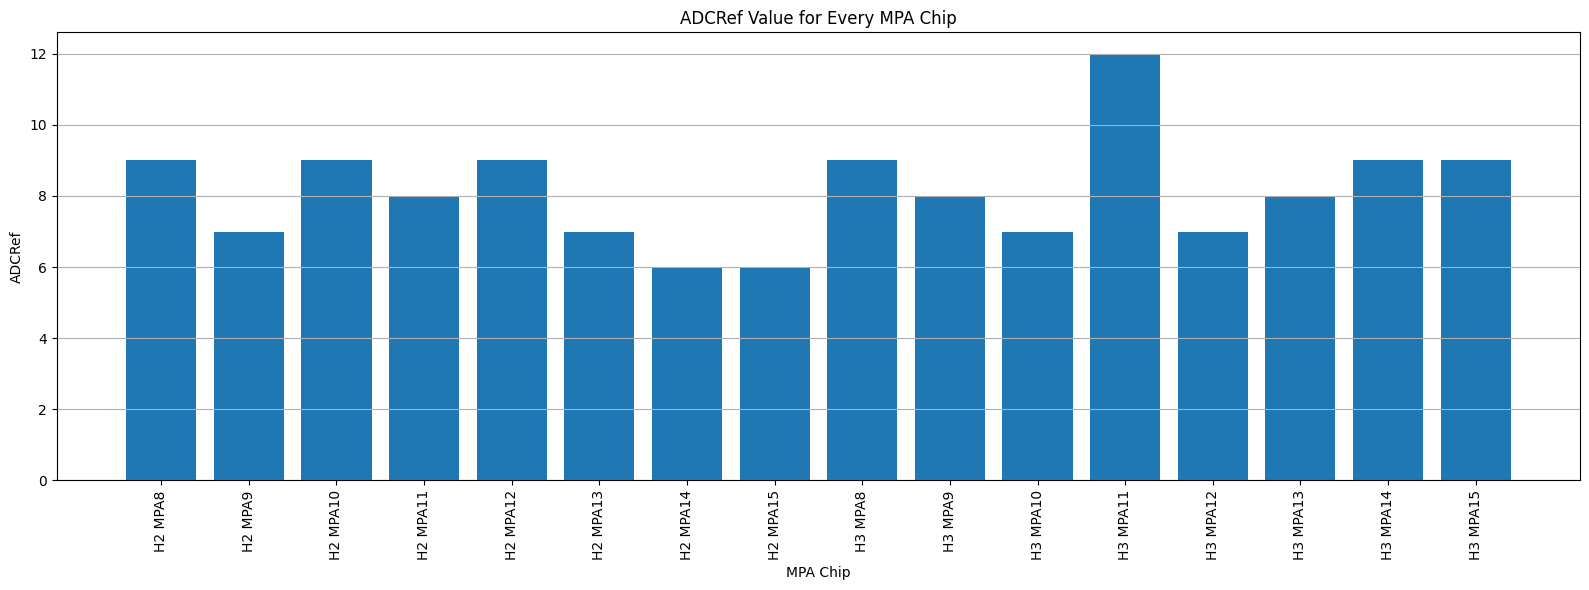

In [8]:
import ROOT
import re
import matplotlib.pyplot as plt

# ROOT file used in your terminal command
fname = "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"

f = ROOT.TFile.Open(fname)

if not f or f.IsZombie():
    raise RuntimeError(f"Cannot open {fname}")

# Storage for plotting
labels = []
adc_refs = []

detector = f.Get("Detector")

for board_key in detector.GetListOfKeys():
    if not board_key.GetName().startswith("Board_"):
        continue

    board = detector.Get(board_key.GetName())
    b = board_key.GetName().split("_")[1]

    for og_key in board.GetListOfKeys():
        if not og_key.GetName().startswith("OpticalGroup_"):
            continue

        og = board.Get(og_key.GetName())
        o = og_key.GetName().split("_")[1]

        for hyb_key in og.GetListOfKeys():
            if not hyb_key.GetName().startswith("Hybrid_"):
                continue

            hybrid = og.Get(hyb_key.GetName())
            h = hyb_key.GetName().split("_")[1]

            for chip_key in hybrid.GetListOfKeys():

                # Find MPA chips
                m = re.match(r"MPA_(\d+)", chip_key.GetName())

                if not m:
                    continue

                chip_id = m.group(1)
                chip_dir = hybrid.Get(chip_key.GetName())

                prefix = f"D_B({b})_O({o})_H({h})"

                name_id = chip_dir.Get(
                    f"{prefix}_NameId_Chip({chip_id})"
                )

                if not name_id:
                    continue

                # Decode FuseID
                fuse_id = int(name_id.GetString().Data())
                fields = split_fuse_id(fuse_id)

                # Store for plot
                labels.append(f"H{h} MPA{chip_id}")
                adc_refs.append(fields["ADCRef"])


f.Close()


# -----------------------------
# Make bar chart
# -----------------------------

plt.figure(figsize=(16,6))

plt.bar(labels, adc_refs)

plt.xlabel("MPA Chip")
plt.ylabel("ADCRef")
plt.title("ADCRef Value for Every MPA Chip")

plt.xticks(rotation=90)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

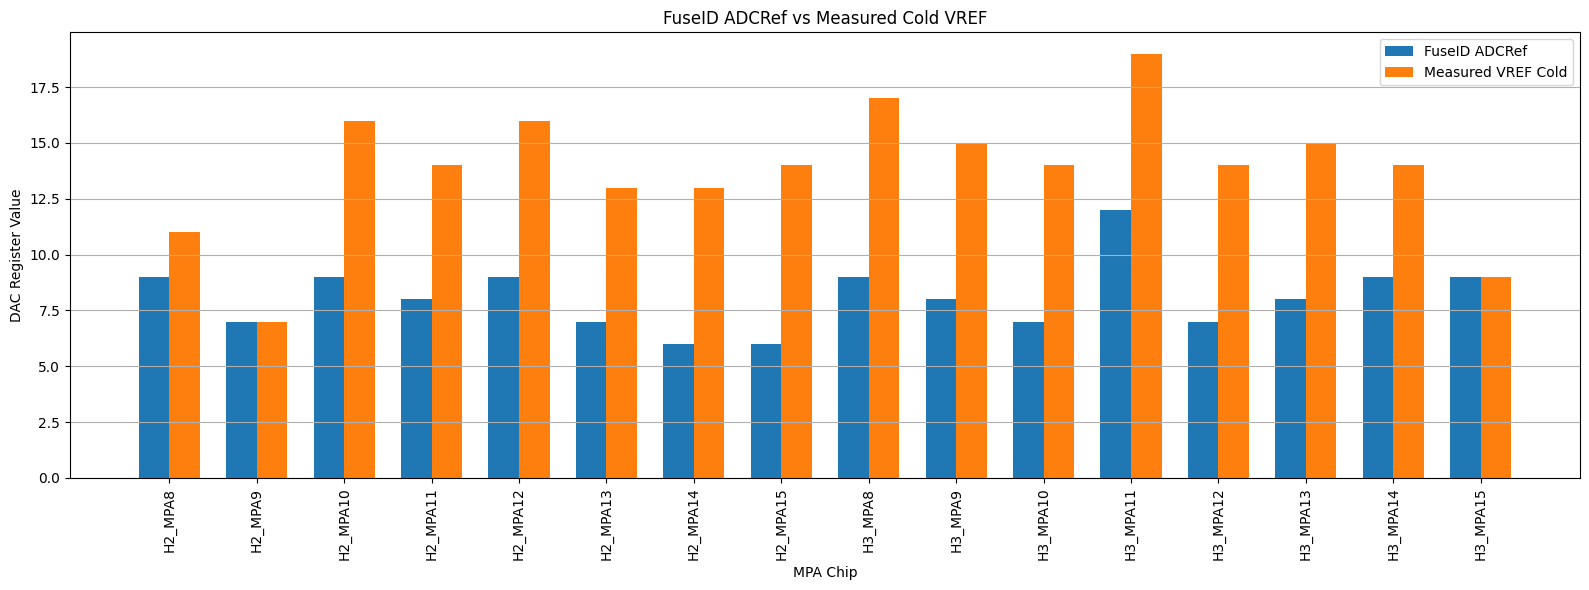

In [10]:
import ROOT
import re
import matplotlib.pyplot as plt
import numpy as np

fname = "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"

f = ROOT.TFile.Open(fname)

if not f or f.IsZombie():
    raise RuntimeError(f"Cannot open {fname}")


def get_vref_dac(hist):
    """Get DAC register from first non-empty histogram bin."""
    for i in range(1, hist.GetNbinsX() + 1):
        if hist.GetBinContent(i) != 0:
            return int(round(hist.GetBinCenter(i)))
    return None


labels = []
fuse_adc_refs = []
measured_dacs = []

detector = f.Get("Detector")

for board_key in detector.GetListOfKeys():

    if not board_key.GetName().startswith("Board_"):
        continue

    board = detector.Get(board_key.GetName())
    b = board_key.GetName().split("_")[1]


    for og_key in board.GetListOfKeys():

        if not og_key.GetName().startswith("OpticalGroup_"):
            continue

        og = board.Get(og_key.GetName())
        o = og_key.GetName().split("_")[1]


        for hyb_key in og.GetListOfKeys():

            if not hyb_key.GetName().startswith("Hybrid_"):
                continue

            hybrid = og.Get(hyb_key.GetName())
            h = hyb_key.GetName().split("_")[1]


            for chip_key in hybrid.GetListOfKeys():

                m = re.match(r"MPA_(\d+)", chip_key.GetName())

                if not m:
                    continue

                chip_id = m.group(1)
                chip_dir = hybrid.Get(chip_key.GetName())

                prefix = f"D_B({b})_O({o})_H({h})"


                # -------------------------
                # Get FuseID ADCRef
                # -------------------------
                name_id = chip_dir.Get(
                    f"{prefix}_NameId_Chip({chip_id})"
                )

                if not name_id:
                    continue

                fuse_id = int(name_id.GetString().Data())

                fields = split_fuse_id(fuse_id)

                fuse_adc = fields["ADCRef"]


                # -------------------------
                # Get measured VREF DAC
                # -------------------------
                vref_hist = chip_dir.Get(
                    f"{prefix}_VREF_DACtoV_Chip({chip_id})"
                )

                if not vref_hist:
                    continue

                measured_dac = get_vref_dac(vref_hist)

                if measured_dac is None:
                    continue


                labels.append(f"H{h}_MPA{chip_id}")
                fuse_adc_refs.append(fuse_adc)
                measured_dacs.append(measured_dac)


f.Close()


# -------------------------
# Plot comparison
# -------------------------

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(16,6))

plt.bar(
    x - width/2,
    fuse_adc_refs,
    width,
    label="FuseID ADCRef"
)

plt.bar(
    x + width/2,
    measured_dacs,
    width,
    label="Measured VREF Cold"
)

plt.xlabel("MPA Chip")
plt.ylabel("DAC Register Value")
plt.title("FuseID ADCRef vs Measured Cold VREF")

plt.xticks(
    x,
    labels,
    rotation=90
)

plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()

ADCRef comparison:
H2_MPA8: FuseID=12, Measured=14 -> MISMATCH
H2_MPA9: FuseID=8, Measured=8 -> OK
H2_MPA10: FuseID=10, Measured=16 -> MISMATCH
H2_MPA11: FuseID=5, Measured=11 -> MISMATCH
H2_MPA12: FuseID=10, Measured=16 -> MISMATCH
H2_MPA13: FuseID=14, Measured=21 -> MISMATCH
H2_MPA14: FuseID=8, Measured=15 -> MISMATCH
H2_MPA15: FuseID=12, Measured=19 -> MISMATCH
H3_MPA8: FuseID=11, Measured=19 -> MISMATCH
H3_MPA9: FuseID=8, Measured=14 -> MISMATCH
H3_MPA10: FuseID=9, Measured=15 -> MISMATCH
H3_MPA11: FuseID=9, Measured=15 -> MISMATCH
H3_MPA12: FuseID=8, Measured=14 -> MISMATCH
H3_MPA13: FuseID=8, Measured=16 -> MISMATCH
H3_MPA14: FuseID=11, Measured=16 -> MISMATCH
H3_MPA15: FuseID=7, Measured=7 -> OK
H4_MPA8: FuseID=9, Measured=12 -> MISMATCH
H4_MPA9: FuseID=7, Measured=7 -> OK
H4_MPA10: FuseID=9, Measured=15 -> MISMATCH
H4_MPA11: FuseID=8, Measured=14 -> MISMATCH
H4_MPA12: FuseID=9, Measured=15 -> MISMATCH
H4_MPA13: FuseID=7, Measured=13 -> MISMATCH
H4_MPA14: FuseID=6, Measured=12 -

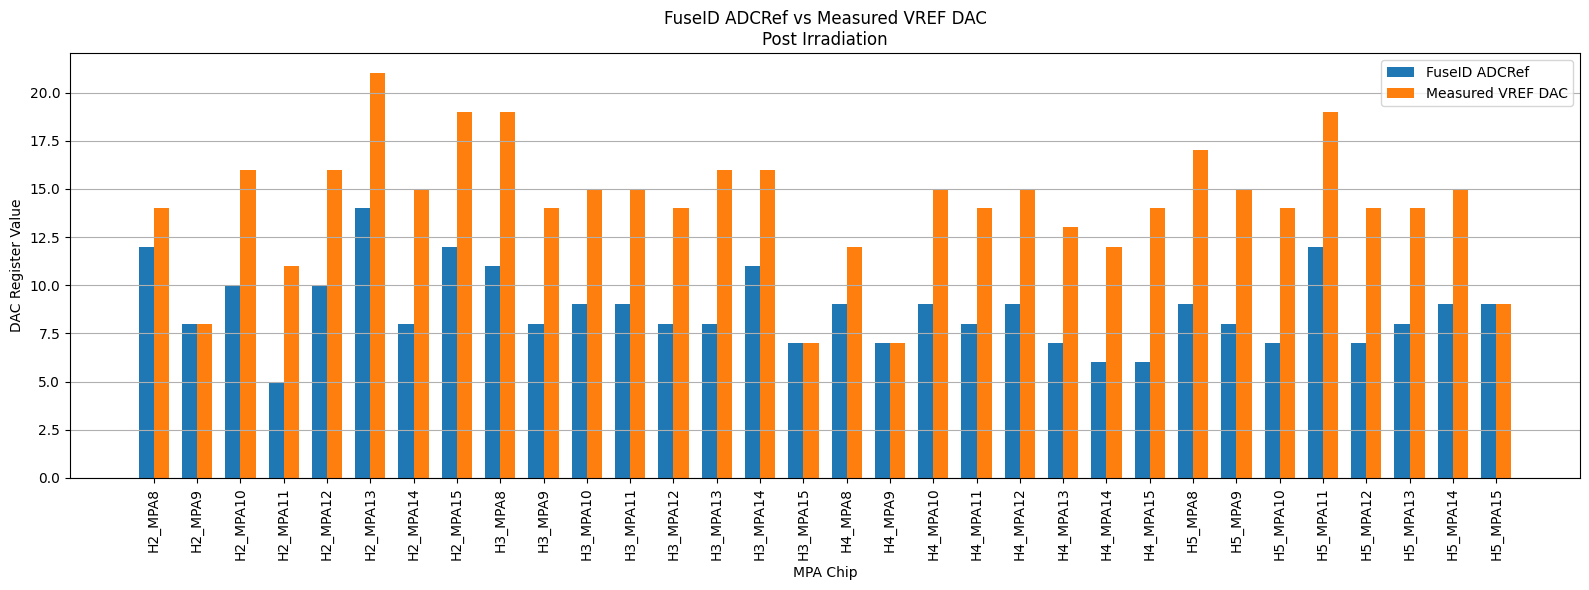

In [13]:
import ROOT
import re
import matplotlib.pyplot as plt
import numpy as np


# New ROOT file
fname = "/home/ekimrey/QPT_before_irradiation/post_irradiation_for_Emerson/TrackerHistos/TrackerHistos_42.root"

f = ROOT.TFile.Open(fname)

if not f or f.IsZombie():
    raise RuntimeError(f"Cannot open {fname}")


def get_vref_dac(hist):
    """Return DAC register from first non-empty VREF_DACtoV histogram bin."""
    for i in range(1, hist.GetNbinsX() + 1):
        if hist.GetBinContent(i) != 0:
            return int(round(hist.GetBinCenter(i)))
    return None


# Store values for plotting
labels = []
fuse_adc_refs = []
measured_dacs = []


# Access Detector inside iteration directory
detector = f.Get(
    "Iteration_1_PSfullTest_2026-03-12_17-23-21/Detector"
)

if not detector:
    raise RuntimeError("Could not find Detector directory")


# Loop through Detector hierarchy
for board_key in detector.GetListOfKeys():

    if not board_key.GetName().startswith("Board_"):
        continue

    board = detector.Get(board_key.GetName())
    b = board_key.GetName().split("_")[1]


    for og_key in board.GetListOfKeys():

        if not og_key.GetName().startswith("OpticalGroup_"):
            continue

        og = board.Get(og_key.GetName())
        o = og_key.GetName().split("_")[1]


        for hyb_key in og.GetListOfKeys():

            if not hyb_key.GetName().startswith("Hybrid_"):
                continue

            hybrid = og.Get(hyb_key.GetName())
            h = hyb_key.GetName().split("_")[1]


            for chip_key in hybrid.GetListOfKeys():

                m = re.match(r"MPA_(\d+)", chip_key.GetName())

                if not m:
                    continue

                chip_id = m.group(1)
                chip_dir = hybrid.Get(chip_key.GetName())

                prefix = f"D_B({b})_O({o})_H({h})"


                # ------------------------
                # Read FuseID ADCRef
                # ------------------------
                name_id = chip_dir.Get(
                    f"{prefix}_NameId_Chip({chip_id})"
                )

                if not name_id:
                    continue

                fuse_id = int(name_id.GetString().Data())

                fields = split_fuse_id(fuse_id)

                adc_ref = fields["ADCRef"]


                # ------------------------
                # Read measured VREF DAC
                # ------------------------
                vref_hist = chip_dir.Get(
                    f"{prefix}_VREF_DACtoV_Chip({chip_id})"
                )

                if not vref_hist:
                    continue

                dac = get_vref_dac(vref_hist)

                if dac is None:
                    continue


                # Save values
                labels.append(f"H{h}_MPA{chip_id}")
                fuse_adc_refs.append(adc_ref)
                measured_dacs.append(dac)


f.Close()


# Print values
print("ADCRef comparison:")
for label, fuse, meas in zip(labels, fuse_adc_refs, measured_dacs):
    status = "OK" if fuse == meas else "MISMATCH"
    print(f"{label}: FuseID={fuse}, Measured={meas} -> {status}")


# ------------------------
# Make comparison bar chart
# ------------------------

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(16,6))

plt.bar(
    x - width/2,
    fuse_adc_refs,
    width,
    label="FuseID ADCRef"
)

plt.bar(
    x + width/2,
    measured_dacs,
    width,
    label="Measured VREF DAC"
)

plt.xlabel("MPA Chip")
plt.ylabel("DAC Register Value")
plt.title("FuseID ADCRef vs Measured VREF DAC\nPost Irradiation")

plt.xticks(
    x,
    labels,
    rotation=90
)

plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()